# Part 1c - Finfing pupil - clearing artifacts away from center

## Setup

In [1]:
import os
import random
import re

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import cv2
from PIL import Image

## Loading images and preprocessing

In [2]:
# Loading and preview ------------------------------------------------

def load_images_ending_with_pattern(folder_path, regex):
    images = []
    pattern = re.compile(regex)

    for root, _, files in os.walk(folder_path):
        for file in files:
            if not pattern.match(file):
                continue
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()
                image = cv2.imread(file_path, cv2.IMREAD_COLOR)
                if image is not None:
                    images.append(image)
            except Exception:
                print(f"Skipping non-image file: {file_path}")
    return images

def preview_images(images, num_previews=5):
    if not images:
        print("No images to display.")
        return

    num_previews = min(num_previews, len(images))
    selected_images = images[:num_previews]
    
    cols = min(15, num_previews)
    rows = math.ceil(num_previews / 15)
    
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, img in enumerate(selected_images):
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Resizing -----------------------------------------------------------

def resize_images(images, max_size=256):
    resized = []
    for img in images:
        h, w = img.shape[:2]
        scale = max_size / max(h, w)
        new_size = (int(w * scale), int(h * scale))  # (width, height)
        resized_img = cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)
        resized.append(resized_img)
    return resized

# Greyscale ----------------------------------------------------------

def convert_images_to_greyscale(images):
    grey_images = []
    for img in images:
        if len(img.shape) == 3:
            grey_img = np.mean(img, axis=2).astype(img.dtype)
        else:
            grey_img = img.copy()
        grey_images.append(grey_img)
    return grey_images

# Binarization -------------------------------------------------------

def adaptive_binarize_pupil(
    grey_images,
    initial_factor,
    white_ratio_thresh=0.9,
    min_factor=1.0,
    factor_step=0.5,
    verbose=False
):
    pupil_binaries = []

    for idx, grey in enumerate(grey_images):
        X = initial_factor
        while True:

            #------------------------------------------
            # Image sizes
            h, w = grey.shape
            # Treshold based on mean
            P = np.sum(grey) / (h * w)
            # Modified treshold
            P = P / X
            # Binarization
            bin_image = np.zeros_like(grey, dtype=np.uint8)
            bin_image[grey >= P] = 255
            #------------------------------------------

            white_ratio = np.mean(bin_image == 255)
            if white_ratio > white_ratio_thresh and (X - factor_step) >= min_factor:
                new_X = round(X - factor_step, 2)
                if verbose:
                    print(
                        f"Image {idx}: white ratio {white_ratio:.3f} > {white_ratio_thresh}, "
                        f"lowering factor {X:.2f} → {new_X:.2f} and retrying"
                    )
                X = new_X
                continue
            break

        # Print final threshold if not verbose
        if not verbose:
            print(
                f"Image {idx}: final threshold P/X = {P/X:.2f} (factor X = {X:.2f}), "
                f"white ratio = {white_ratio:.3f}"
            )

        pupil_binaries.append(bin_image)

    return pupil_binaries

# Morphologial operations --------------------------------------------

def get_structuring_element(shape, ksize, anchor=None):
    rows, cols = ksize
    if anchor is None:
        anchor = (rows // 2, cols // 2)
    if shape.lower() == "rect":
        kernel = np.ones((rows, cols), dtype=np.uint8)
    elif shape.lower() == "ellipse":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Use the center of the kernel for ellipse definition.
        cy, cx = rows // 2, cols // 2  
        a = rows / 2.0
        b = cols / 2.0
        for i in range(rows):
            for j in range(cols):
                # Equation of ellipse centered at (cy, cx)
                if ((i - cy) / a)**2 + ((j - cx) / b)**2 <= 1:
                    kernel[i, j] = 1
    elif shape.lower() == "cross":
        kernel = np.zeros((rows, cols), dtype=np.uint8)
        # Place ones in the row and column corresponding to anchor
        ay, ax = anchor
        if 0 <= ay < rows:
            kernel[ay, :] = 1
        if 0 <= ax < cols:
            kernel[:, ax] = 1
    else:
        raise ValueError("Unsupported kernel shape. Choose 'rect', 'ellipse', or 'cross'.")
    return kernel, anchor

def erosion(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.min())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.max(region[kernel==1])
    return out

def dilation(image, kernel, anchor):
    krows, kcols = kernel.shape
    ay, ax = anchor
    pad_top = ay
    pad_bottom = krows - ay - 1
    pad_left = ax
    pad_right = kcols - ax - 1
    padded = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), mode='constant', constant_values=image.max())
    out = np.zeros_like(image)
    rows, cols = image.shape
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+krows, j:j+kcols]
            out[i, j] = np.min(region[kernel==1])
    return out

def opening(image, kernel, anchor):
    eroded = erosion(image, kernel, anchor)
    opened = dilation(eroded, kernel, anchor)
    return opened

def closing(image, kernel, anchor):
    dilated = dilation(image, kernel, anchor)
    closed = erosion(dilated, kernel, anchor)
    return closed

## Removing elements away from image's center

In [3]:
def mask_outside_boundary(images, x_thresh=0.9, y_thresh=0.9):
    masked = []
    for img in images:
        h, w = img.shape[:2]
        cx, cy = w/2.0, h/2.0
        dx, dy = x_thresh*(w/2.0), y_thresh*(h/2.0)
        left, right   = cx - dx, cx + dx
        top, bottom   = cy - dy, cy + dy

        # Create a boolean mask of pixels to white‑out:
        ys, xs = np.ogrid[:h, :w]
        outside = (xs < left) | (xs > right) | (ys < top) | (ys > bottom)

        out = img.copy()
        if img.ndim == 2:
            out[outside] = 255
        else:
            out[outside] = (255, 255, 255)
        masked.append(out)
    return masked

def draw_boundary_on_images(images, x_thresh=0.9, y_thresh=0.9, color=(0, 0, 255), thickness=2):
    bordered_images = []
    for img in images:
        if len(img.shape) == 2:
            # convert grayscale to BGR for color rectangle
            display = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
            display = img.copy()

        h, w = img.shape[:2]
        cx, cy = w / 2.0, h / 2.0
        dx = x_thresh * (w / 2.0)
        dy = y_thresh * (h / 2.0)

        # top-left and bottom-right points of rectangle
        pt1 = (int(cx - dx), int(cy - dy))
        pt2 = (int(cx + dx), int(cy + dy))
        cv2.rectangle(display, pt1, pt2, color, thickness)
        bordered_images.append(display)
    return bordered_images

### On MMU-Iris-Database data set with its parameters for closing

Image 0: final threshold P/X = 5.66 (factor X = 5.70), white ratio = 0.975
Image 1: final threshold P/X = 6.27 (factor X = 5.30), white ratio = 0.974
Image 2: final threshold P/X = 3.79 (factor X = 6.35), white ratio = 0.974
Image 3: final threshold P/X = 3.80 (factor X = 6.60), white ratio = 0.969
Image 4: final threshold P/X = 7.93 (factor X = 4.55), white ratio = 0.975
Image 5: final threshold P/X = 6.20 (factor X = 5.20), white ratio = 0.975
Image 6: final threshold P/X = 3.59 (factor X = 7.00), white ratio = 0.975
Image 7: final threshold P/X = 3.09 (factor X = 7.15), white ratio = 0.975
Image 8: final threshold P/X = 7.74 (factor X = 4.40), white ratio = 0.975
Image 9: final threshold P/X = 6.92 (factor X = 4.65), white ratio = 0.974
Image 10: final threshold P/X = 4.96 (factor X = 6.05), white ratio = 0.975
Image 11: final threshold P/X = 7.44 (factor X = 5.00), white ratio = 0.975
Image 12: final threshold P/X = 15.77 (factor X = 3.15), white ratio = 0.973
Image 13: final thres

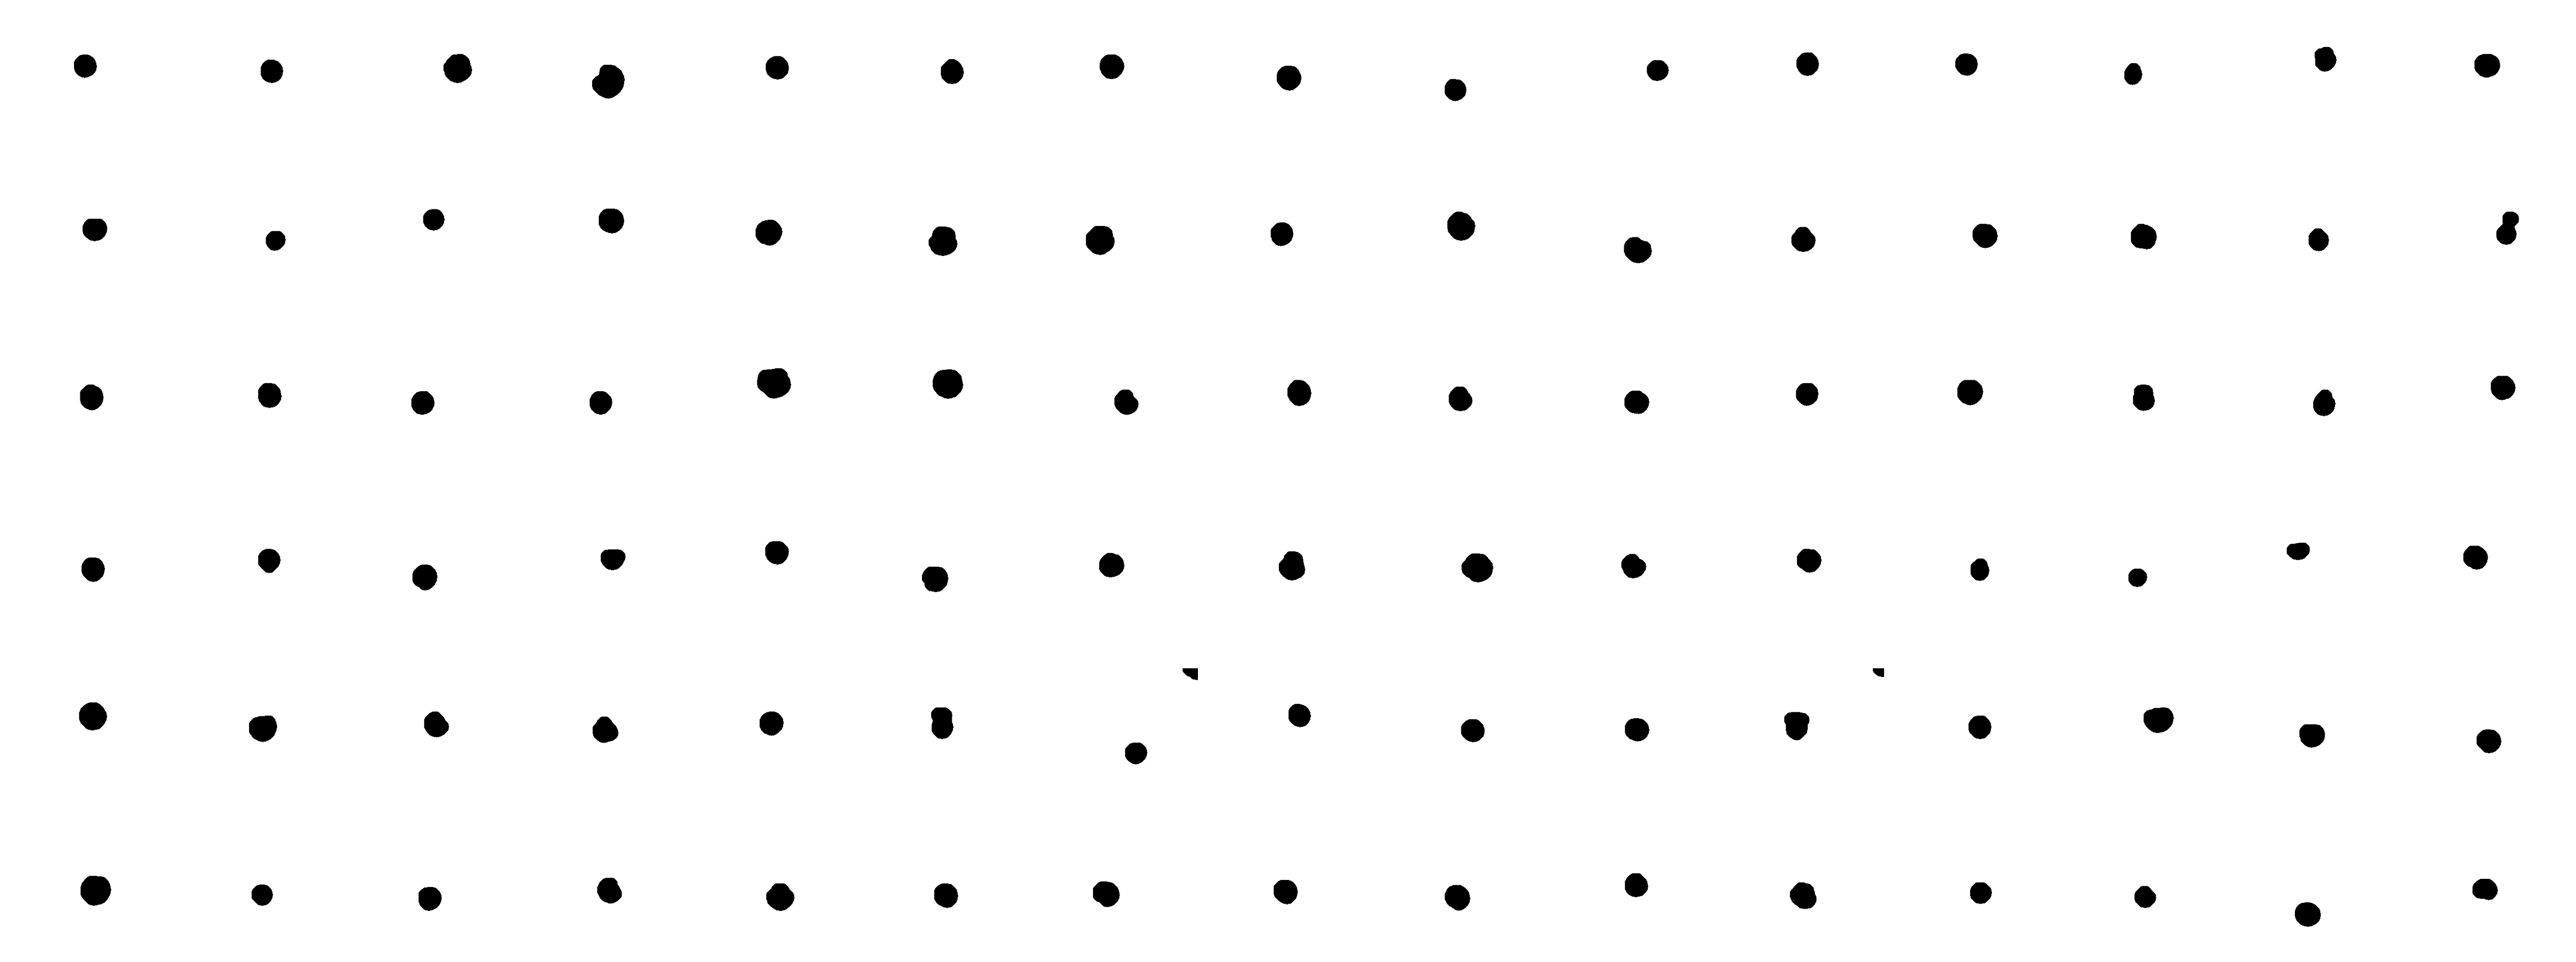

In [4]:
# Loading
images = load_images_ending_with_pattern('MMU-Iris-Database', r'.*[^0-9]?1\.[a-zA-Z]+$')

# Greyscale
grey_images = convert_images_to_greyscale(images)

# Binarization
binarized_pupil_images = adaptive_binarize_pupil(
        grey_images,
        initial_factor=15,
        white_ratio_thresh=0.975,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (5.5/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (10/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_images = [opening(img, structuring_element, anchor) for img in closed_images]

preview_images(opened_images, num_previews=len(opened_images))

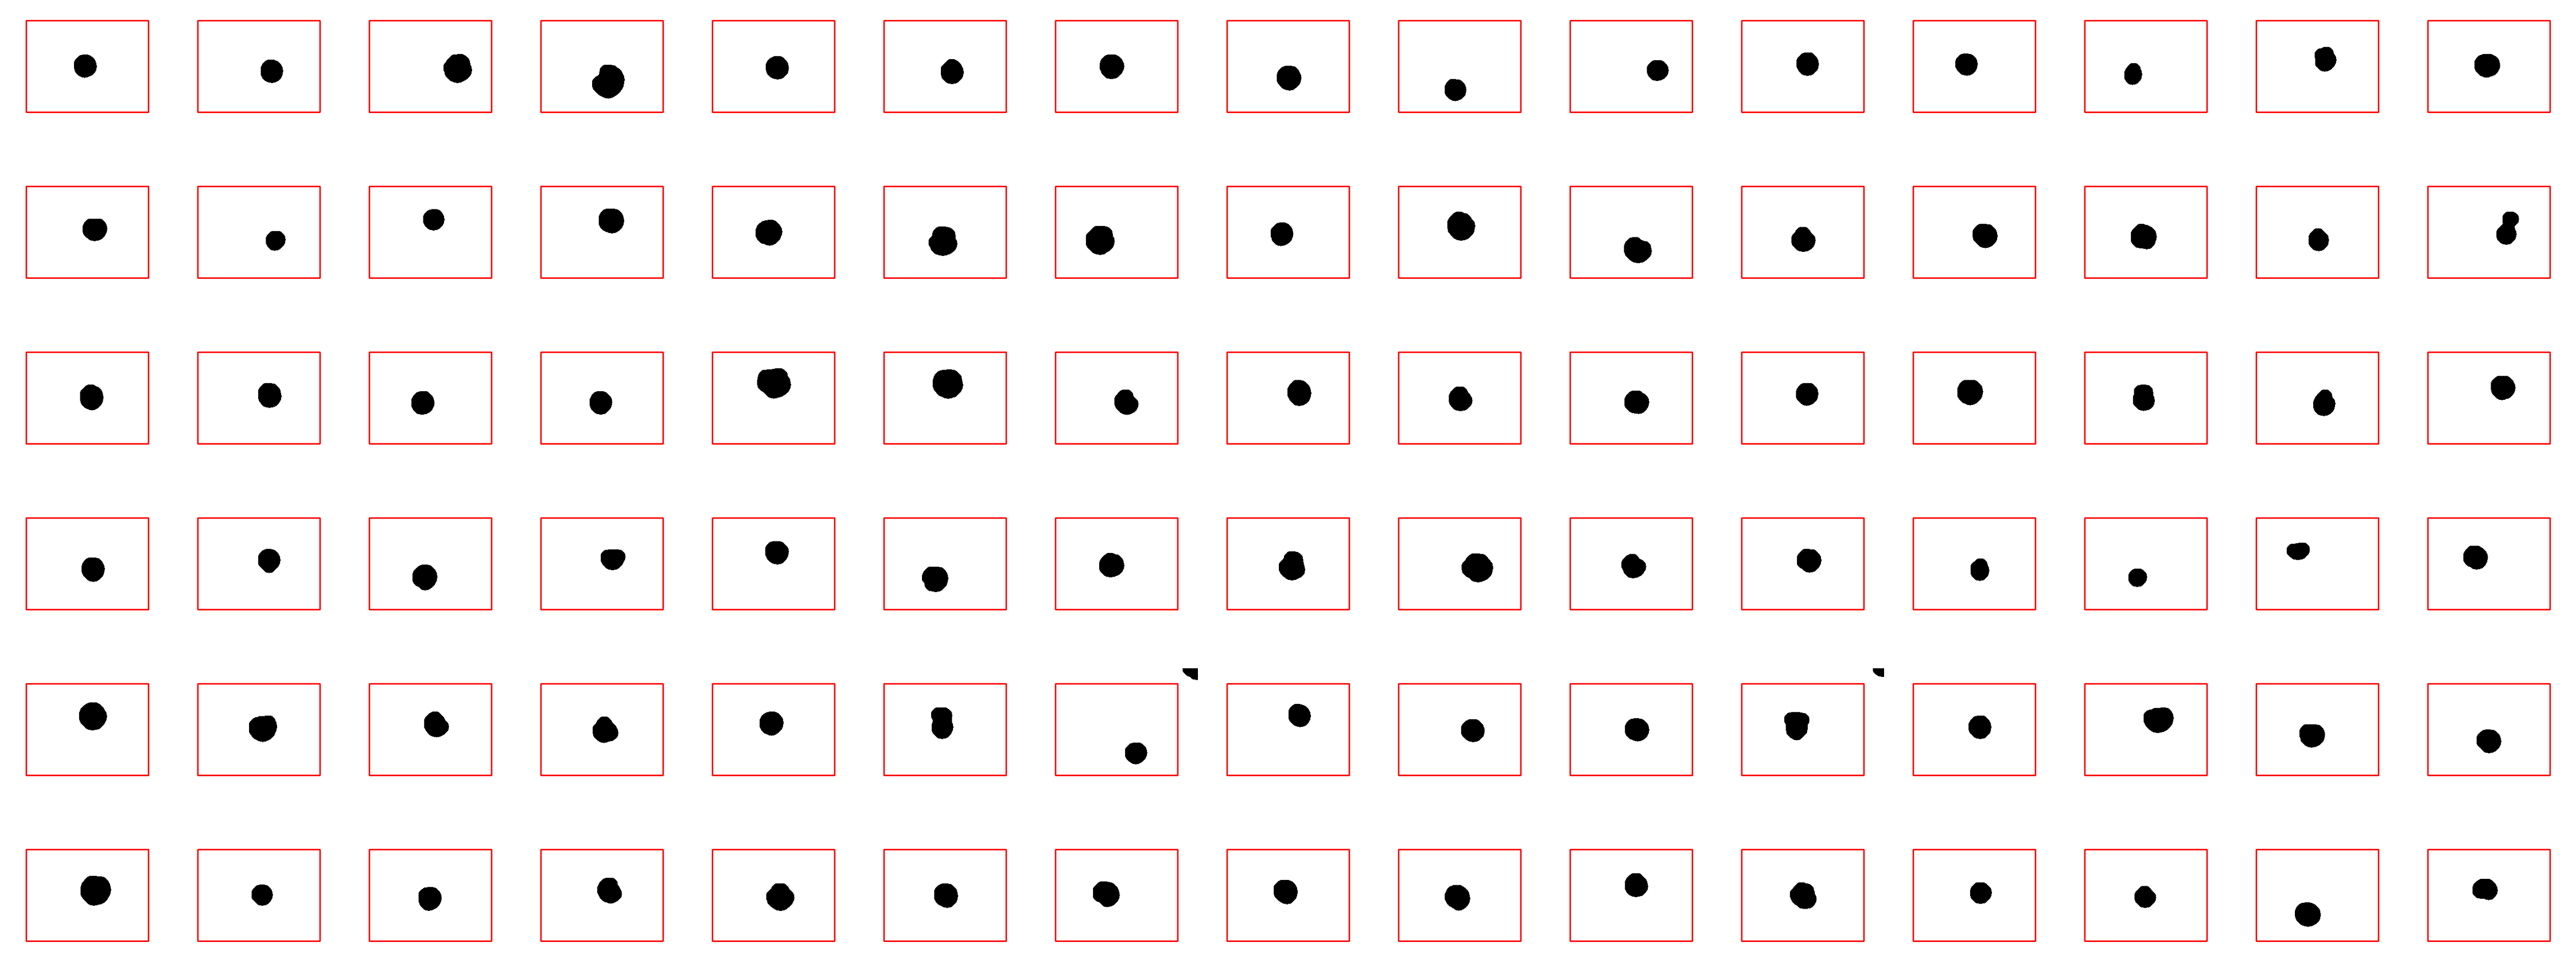

In [5]:
x_axis_threshold = 0.75
y_axis_threshold = 0.75
bordered = draw_boundary_on_images(opened_images, x_thresh=x_axis_threshold, y_thresh=y_axis_threshold)
preview_images(bordered, num_previews=len(bordered))

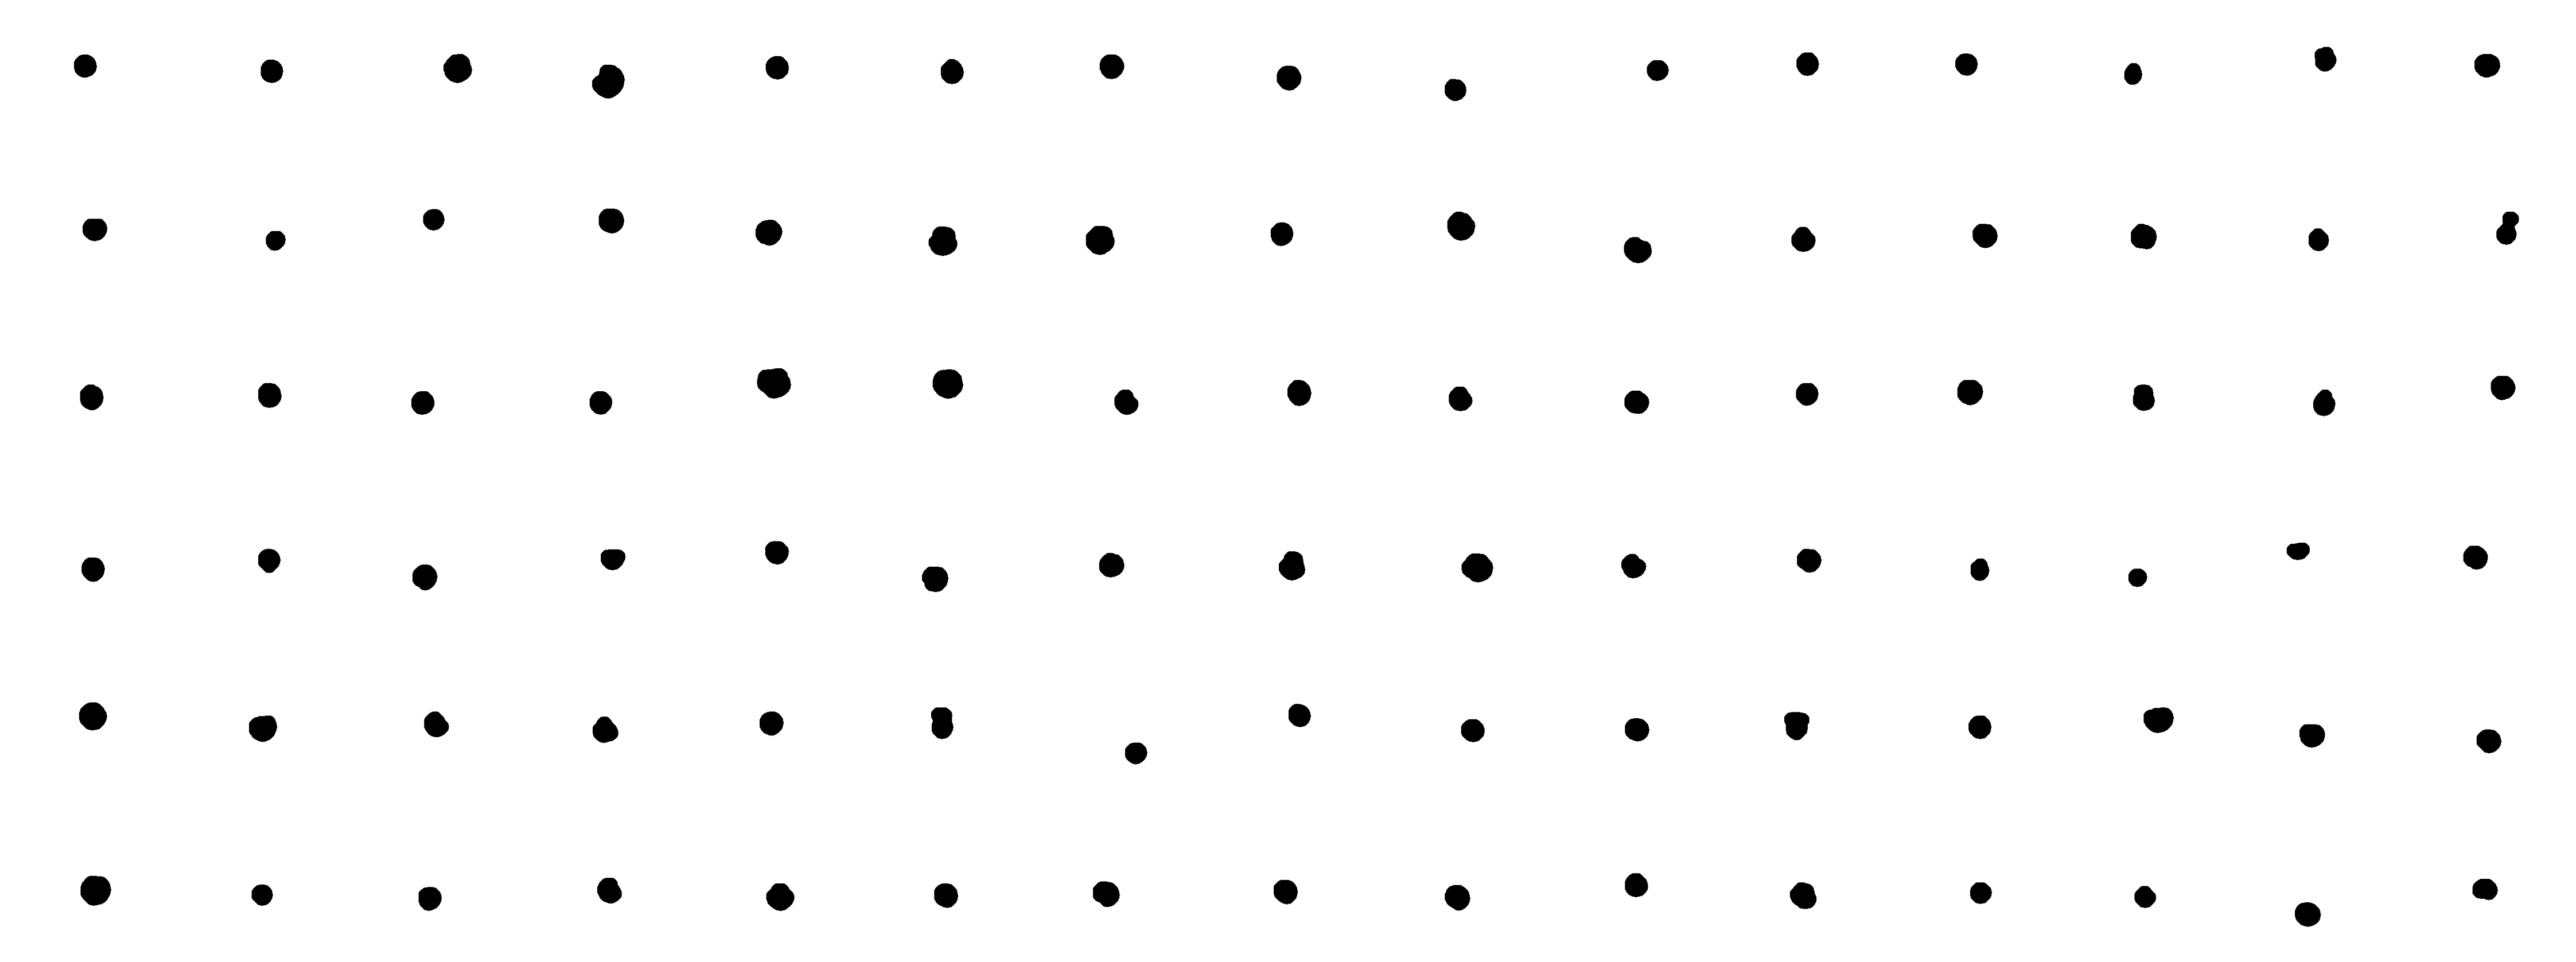

In [6]:
masked = mask_outside_boundary(opened_images, x_thresh=x_axis_threshold, y_thresh=y_axis_threshold)
preview_images(masked, num_previews=len(masked))

### On MMU-Iris-Database data set with teczowka_data's parameters for closing

Image 0: final threshold P/X = 5.66 (factor X = 5.70), white ratio = 0.975
Image 1: final threshold P/X = 6.27 (factor X = 5.30), white ratio = 0.974
Image 2: final threshold P/X = 3.79 (factor X = 6.35), white ratio = 0.974
Image 3: final threshold P/X = 3.80 (factor X = 6.60), white ratio = 0.969
Image 4: final threshold P/X = 7.93 (factor X = 4.55), white ratio = 0.975
Image 5: final threshold P/X = 6.20 (factor X = 5.20), white ratio = 0.975
Image 6: final threshold P/X = 3.59 (factor X = 7.00), white ratio = 0.975
Image 7: final threshold P/X = 3.09 (factor X = 7.15), white ratio = 0.975
Image 8: final threshold P/X = 7.74 (factor X = 4.40), white ratio = 0.975
Image 9: final threshold P/X = 6.92 (factor X = 4.65), white ratio = 0.974
Image 10: final threshold P/X = 4.96 (factor X = 6.05), white ratio = 0.975
Image 11: final threshold P/X = 7.44 (factor X = 5.00), white ratio = 0.975
Image 12: final threshold P/X = 15.77 (factor X = 3.15), white ratio = 0.973
Image 13: final thres

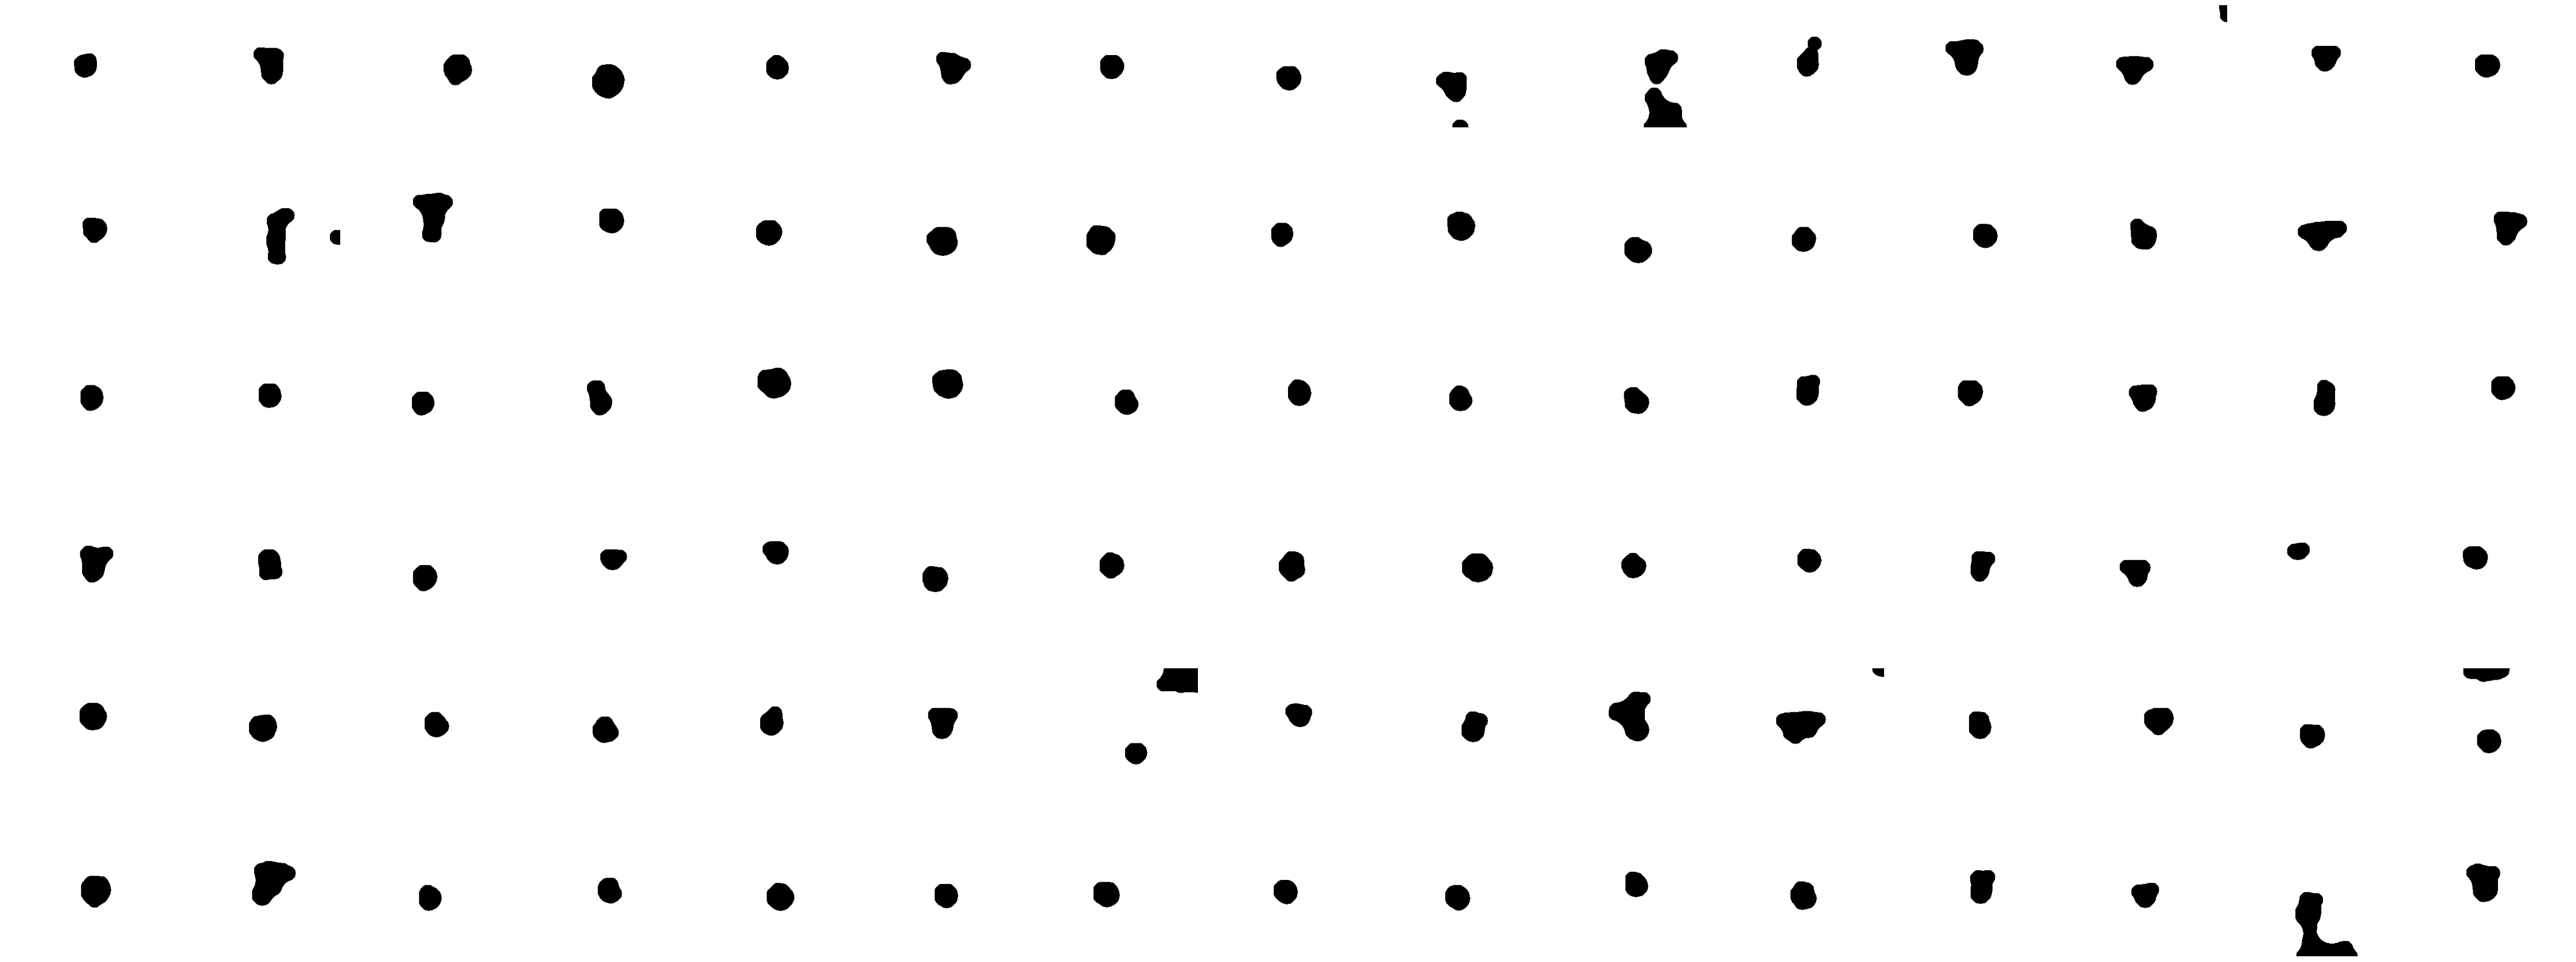

In [7]:
# Loading
images = load_images_ending_with_pattern('MMU-Iris-Database', r'.*[^0-9]?1\.[a-zA-Z]+$')

# Greyscale
grey_images = convert_images_to_greyscale(images)

# Binarization
binarized_pupil_images = adaptive_binarize_pupil(
        grey_images,
        initial_factor=15,
        white_ratio_thresh=0.975,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (20/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (10/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_images = [opening(img, structuring_element, anchor) for img in closed_images]

preview_images(opened_images, num_previews=len(opened_images))

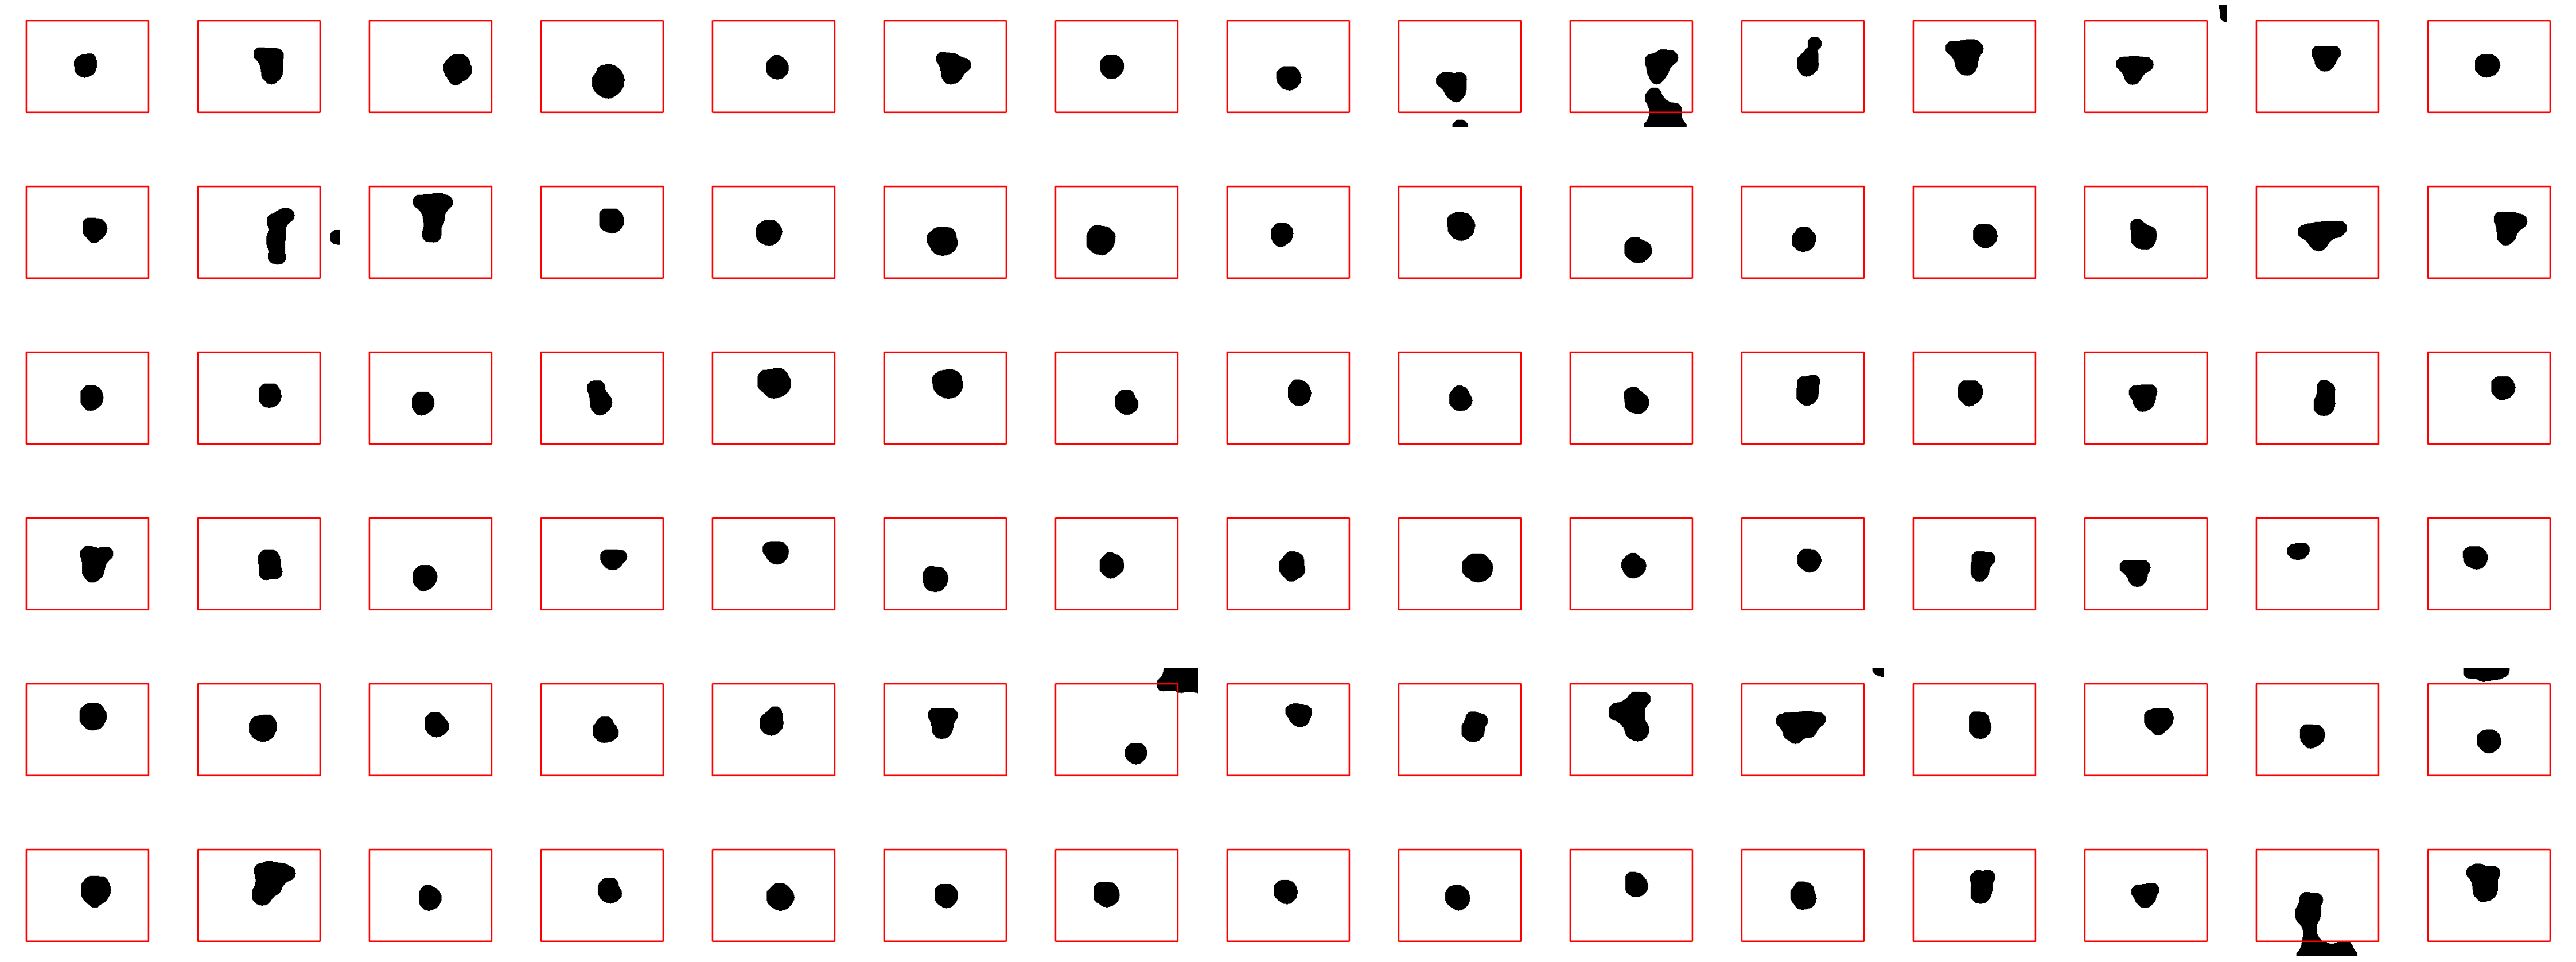

In [8]:
x_axis_threshold = 0.75
y_axis_threshold = 0.75
bordered = draw_boundary_on_images(opened_images, x_thresh=x_axis_threshold, y_thresh=y_axis_threshold)
preview_images(bordered, num_previews=len(bordered))

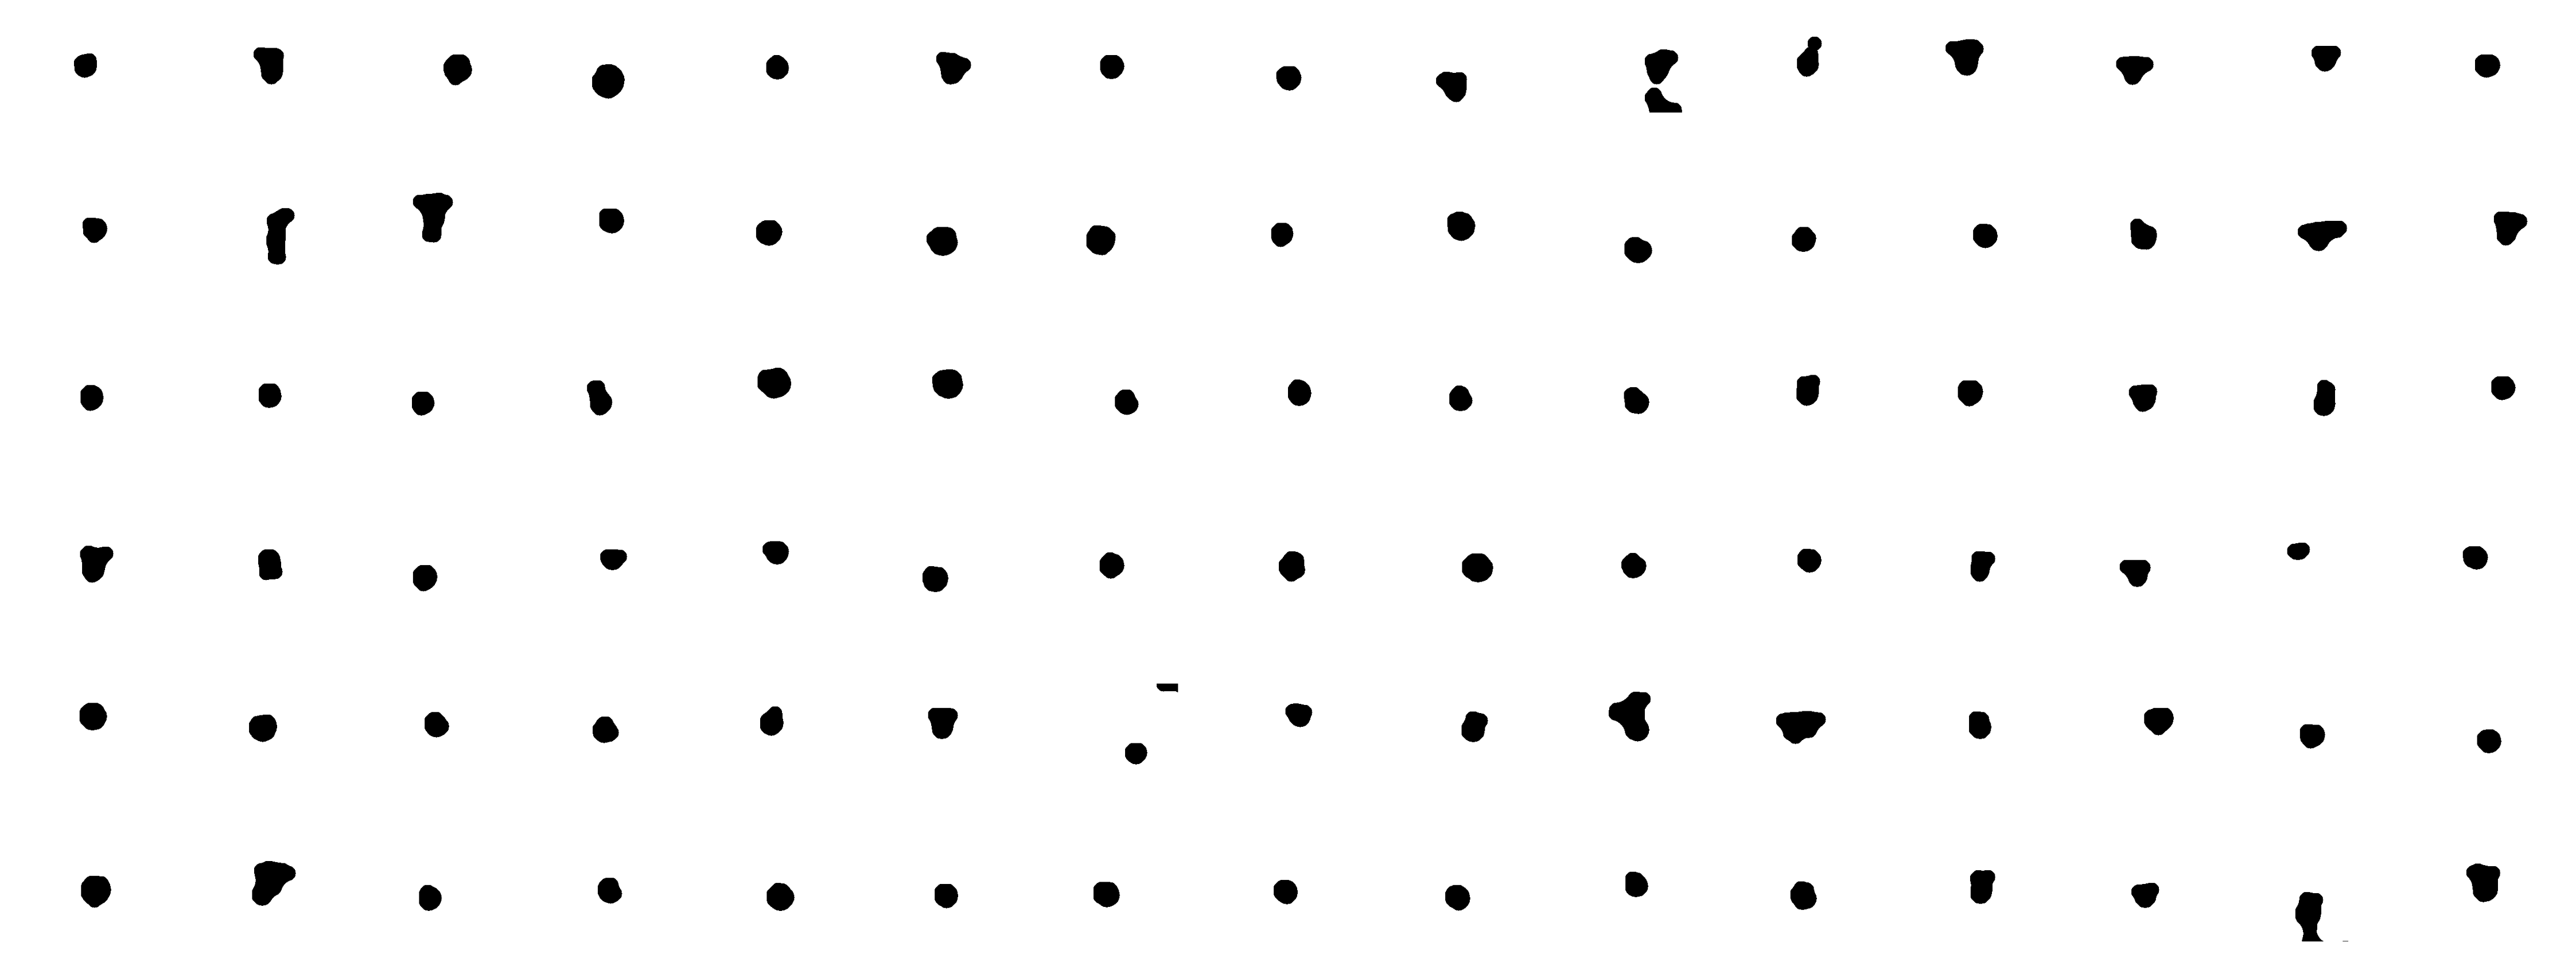

In [9]:
masked = mask_outside_boundary(opened_images, x_thresh=x_axis_threshold, y_thresh=y_axis_threshold)
preview_images(masked, num_previews=len(masked))

### On teczowka_data data set with its parameters for closing

Image 0: final threshold P/X = 6.17 (factor X = 5.05), white ratio = 0.968
Image 1: final threshold P/X = 6.98 (factor X = 4.75), white ratio = 0.973
Image 2: final threshold P/X = 11.67 (factor X = 3.60), white ratio = 0.972
Image 3: final threshold P/X = 3.88 (factor X = 5.70), white ratio = 0.973
Image 4: final threshold P/X = 3.16 (factor X = 5.10), white ratio = 0.967
Image 5: final threshold P/X = 6.15 (factor X = 4.75), white ratio = 0.972
Image 6: final threshold P/X = 4.58 (factor X = 5.25), white ratio = 0.969
Image 7: final threshold P/X = 3.55 (factor X = 5.65), white ratio = 0.970
Image 8: final threshold P/X = 2.84 (factor X = 6.00), white ratio = 0.966
Image 9: final threshold P/X = 5.59 (factor X = 4.85), white ratio = 0.972
Image 10: final threshold P/X = 8.07 (factor X = 4.25), white ratio = 0.974
Image 11: final threshold P/X = 6.58 (factor X = 4.60), white ratio = 0.975
Image 12: final threshold P/X = 6.69 (factor X = 4.20), white ratio = 0.972
Image 13: final thres

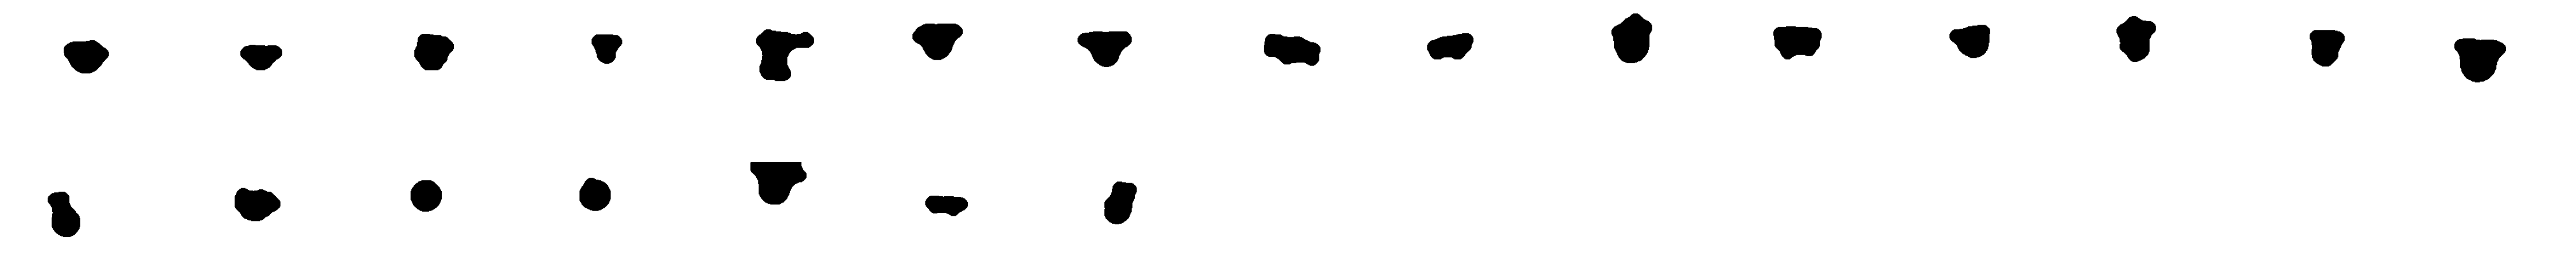

In [10]:
# Loading
images = load_images_ending_with_pattern('teczowka_data', r'.*[^0-9]?1\.[a-zA-Z]+$')

# Resizing
images = resize_images(images, max_size=256)

# Greyscale
grey_images = convert_images_to_greyscale(images)

# Binarization
binarized_pupil_images = adaptive_binarize_pupil(
        grey_images,
        initial_factor=15,
        white_ratio_thresh=0.975,
        min_factor=1.0,
        factor_step=0.05,
        verbose=False
)

# Closing
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (20/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
closed_images = [closing(img, structuring_element, anchor) for img in binarized_pupil_images]

# Opening
kernel_size = math.floor(np.mean(binarized_pupil_images[0].shape) * (10/100))
structuring_element, anchor = get_structuring_element(shape="ellipse", ksize=(kernel_size, kernel_size), anchor=None)
opened_images = [opening(img, structuring_element, anchor) for img in closed_images]

preview_images(opened_images, num_previews=len(opened_images))

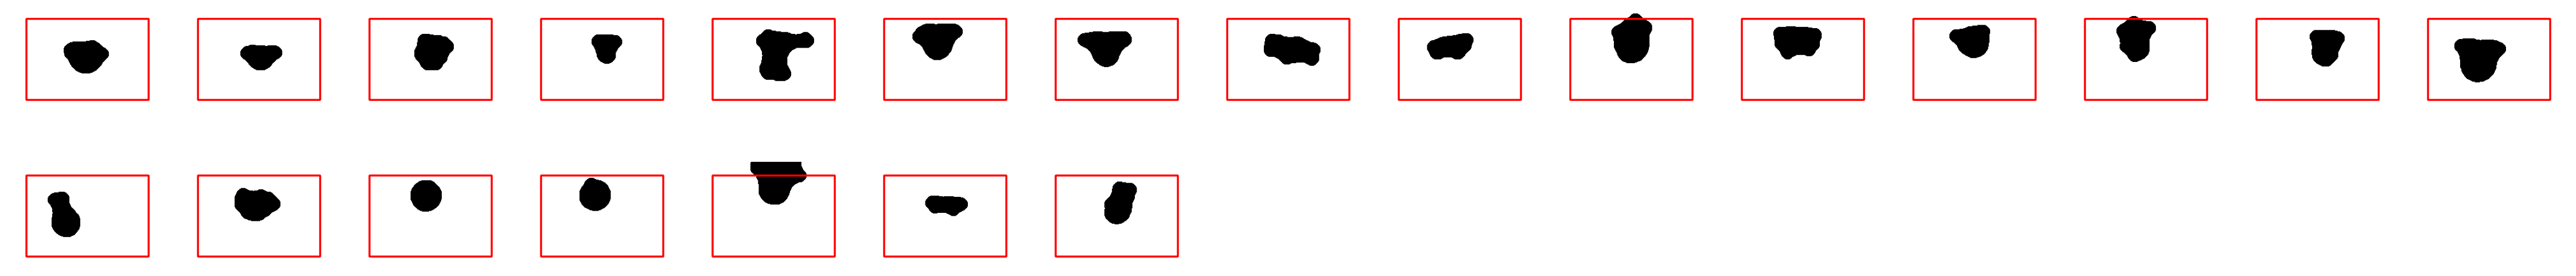

In [11]:
x_axis_threshold = 0.75
y_axis_threshold = 0.75
bordered = draw_boundary_on_images(opened_images, x_thresh=x_axis_threshold, y_thresh=y_axis_threshold)
preview_images(bordered, num_previews=len(bordered))

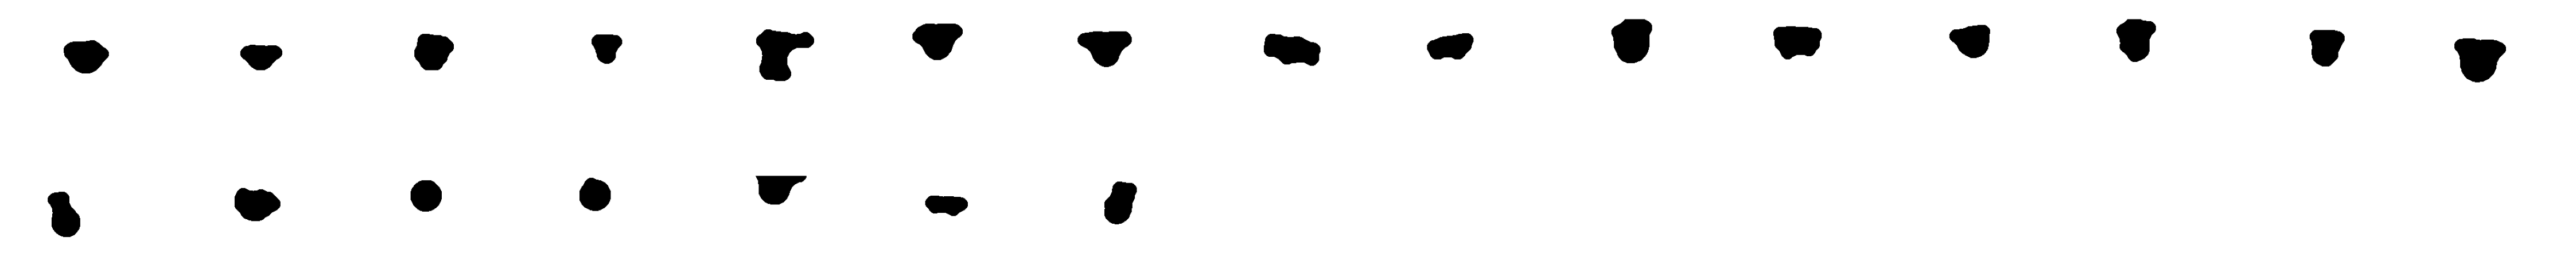

In [12]:
masked = mask_outside_boundary(opened_images, x_thresh=0.75, y_thresh=0.75)
preview_images(masked, num_previews=len(masked))